<h1>Chapter 5 | Data Exercise #3 | <code>hotels-europe</code> | Generalizing from Data</h1>


<h2>Introduction:</h2>
<p>In this notebook, you will find my notes and code for Chapter 5's <b>exercise 3</b> of the book <a href="https://gabors-data-analysis.com/">Data Analysis for Business, Economics, and Policy</a>, by Gábor Békés and Gábor Kézdi. The question was: 
<p>3. Use <code>hotels-europe</code> dataset and pick two cities and the same date.
<p>Assignments:</p>
<ul>
    <li>In each city, take hotels with three stars and calculate the average price.</li>
    <li>Estimate the standard error of the estimated average price by bootsrap and using the SE formula.</li>
    <li>Create 95% confidence intervals.</li>
    <li>Compare the average price and the confidence intervals across the two cities, and explain why you have a narrower CI for one city than the other..</li>


</ul>
<h2>1. Load the data</h2>

In [ ]:
import os
import pandas as pd
import warnings
from datetime import datetime
from plotnine import *
import sys
import numpy as np
from scipy.stats import norm, sem
from numpy.random import choice
warnings.filterwarnings("ignore")

In [ ]:
# Increase number of returned rows in pandas
pd.set_option("display.max_rows", 500)

In [ ]:
# Current script folder
dirname = os.getcwd()

# Get location folders
data_in = f"{dirname}/da_data_repo/hotels-europe/clean/"
data_out = f"{dirname}/da_data_exercises/ch05-generalizing_from_data/03-hotels_europe/data/clean/"
output = f"{dirname}/da_data_exercises/ch05-generalizing_from_data/03-hotels_europe/data/output/"
func = f"{dirname}/da_case_studies/ch00-tech_prep/"
sys.path.append(func)
paths = [data_in, data_out, output]

for path in paths:
    if not os.path.exists(path):
        os.makedirs(path)

In [ ]:
# Import the prewritten helper functions 
from py_helper_functions import *

In [ ]:
data_europe = pd.read_csv(f"{data_in}hotels-europe_price.csv")

In [ ]:
data_europe.head()

,hotel_id,price,offer,offer_cat,year,month,weekend,holiday,nnights,scarce_room
0,1,172,0,0% no offer,2017,11,1,0,1,0
1,1,122,1,15-50% offer,2018,1,1,0,1,0
2,1,122,1,15-50% offer,2017,12,0,1,1,0
3,1,552,1,1-15% offer,2017,12,0,1,4,0
4,1,122,1,15-50% offer,2018,2,1,0,1,0


We probably need to do some data manipulation to get our features, which probably are at `hotels-europe_features.csv`.

In [ ]:
hotels_europe_features = pd.read_csv(f"{data_in}hotels-europe_features.csv", header=0, skiprows=[1])

In [ ]:
hotels_europe_features

,hotel_id,city,distance,stars,rating,country,city_actual,rating_reviewcount,center1label,center2label,neighbourhood,ratingta,ratingta_count,distance_alter,accommodation_type
0,3,Amsterdam,1.5,4.0,4.1,Netherlands,Amsterdam,165.0,City centre,Montelbaanstoren,Amsterdam,4.0,674.0,1.4,Hotel
1,4,Amsterdam,1.9,3.0,3.5,Netherlands,Amsterdam,298.0,City centre,Montelbaanstoren,Amsterdam,3.5,1882.0,2.1,Hotel
2,5,Amsterdam,1.8,3.5,4.0,Netherlands,Amsterdam,4.0,City centre,Montelbaanstoren,Amsterdam,4.5,66.0,2.0,Hotel
3,6,Amsterdam,1.9,4.0,4.1,Netherlands,Amsterdam,310.0,City centre,Montelbaanstoren,Amsterdam,4.0,767.0,2.0,Hotel
4,7,Amsterdam,0.8,3.5,4.4,Netherlands,Amsterdam,258.0,City centre,Montelbaanstoren,Amsterdam,4.5,273.0,1.2,Hotel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22896,19109,Rome,0.4,NaN,3.9,Italy,Rome,68.0,City centre,Grotta del Bue Marino,Trevi Fountain,4.0,100.0,0.7,Bed and breakfast
22897,19114,Rome,0.4,4.0,4.3,Italy,Rome,168.0,City centre,Palazzo Madama,Trevi Fountain,4.0,212.0,0.7,Hotel
22898,19115,Rome,0.4,NaN,4.3,Italy,Rome,44.0,City centre,Grotta del Bue Marino,Trevi Fountain,4.0,512.0,0.7,Guest House
22899,1,Amsterdam,3.1,4.0,4.3,Netherlands,Amsterdam,1030.0,City centre,Montelbaanstoren,Amsterdam,4.0,1115.0,3.6,Hotel


Ok, we'll work on this table first, select two cities and then join it with our facts table. We'll use Amsterdam and Madrid.

In [ ]:
selected_cities = ["Amsterdam", "Madrid"]
hotels_cut_direct = hotels_europe_features[hotels_europe_features["city_actual"].isin(selected_cities)]

In [ ]:
hotels_cut_direct["city_actual"].unique()

array(['Amsterdam', 'Madrid'], dtype=object)

In [ ]:
hotels_cut_direct.head()

,hotel_id,city,distance,stars,rating,country,city_actual,rating_reviewcount,center1label,center2label,neighbourhood,ratingta,ratingta_count,distance_alter,accommodation_type
0,3,Amsterdam,1.5,4.0,4.1,Netherlands,Amsterdam,165.0,City centre,Montelbaanstoren,Amsterdam,4.0,674.0,1.4,Hotel
1,4,Amsterdam,1.9,3.0,3.5,Netherlands,Amsterdam,298.0,City centre,Montelbaanstoren,Amsterdam,3.5,1882.0,2.1,Hotel
2,5,Amsterdam,1.8,3.5,4.0,Netherlands,Amsterdam,4.0,City centre,Montelbaanstoren,Amsterdam,4.5,66.0,2.0,Hotel
3,6,Amsterdam,1.9,4.0,4.1,Netherlands,Amsterdam,310.0,City centre,Montelbaanstoren,Amsterdam,4.0,767.0,2.0,Hotel
4,7,Amsterdam,0.8,3.5,4.4,Netherlands,Amsterdam,258.0,City centre,Montelbaanstoren,Amsterdam,4.5,273.0,1.2,Hotel


In [ ]:
# Recommended approach for your analysis
# Clean, readable, and performant
hotels_cut = hotels_europe_features[
    (hotels_europe_features["city_actual"].isin(selected_cities)) &
    (hotels_europe_features["accommodation_type"] == "Hotel") &
    (hotels_europe_features["stars"] == 3.0)
]

print("Final filtered dataset for analysis:")
print(f"Total hotels: {len(hotels_cut)}")
print("\nBreakdown by city:")
print(hotels_cut.groupby('city').size())

# Let's also check what columns we have available for the next steps
print(f"\nColumns available: {list(hotels_cut.columns)}")

Final filtered dataset for analysis:
Total hotels: 176

Breakdown by city:
city
Amsterdam    109
Madrid        67
dtype: int64

Columns available: ['hotel_id', 'city', 'distance', 'stars', 'rating', 'country', 'city_actual', 'rating_reviewcount', 'center1label', 'center2label', 'neighbourhood', 'ratingta', 'ratingta_count', 'distance_alter', 'accommodation_type']


We can now join both datasets.

In [ ]:
hotels_df = pd.merge(hotels_cut, data_europe, on="hotel_id", how="left")

In [ ]:
hotels_df

,hotel_id,city,distance,stars,rating,country,city_actual,rating_reviewcount,center1label,center2label,...,accommodation_type,price,offer,offer_cat,year,month,weekend,holiday,nnights,scarce_room
0,4,Amsterdam,1.9,3.0,3.5,Netherlands,Amsterdam,298.0,City centre,Montelbaanstoren,...,Hotel,115,1,15-50% offer,2017,12,0,1,1,0
1,4,Amsterdam,1.9,3.0,3.5,Netherlands,Amsterdam,298.0,City centre,Montelbaanstoren,...,Hotel,71,1,50%-75% offer,2017,11,0,0,1,0
2,11,Amsterdam,2.2,3.0,3.7,Netherlands,Amsterdam,341.0,City centre,Montelbaanstoren,...,Hotel,97,1,15-50% offer,2017,11,0,0,1,0
3,11,Amsterdam,2.2,3.0,3.7,Netherlands,Amsterdam,341.0,City centre,Montelbaanstoren,...,Hotel,167,0,0% no offer,2017,11,1,0,1,0
4,11,Amsterdam,2.2,3.0,3.7,Netherlands,Amsterdam,341.0,City centre,Montelbaanstoren,...,Hotel,105,1,15-50% offer,2018,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1114,9554,Madrid,3.2,3.0,3.9,Spain,Madrid,208.0,City centre,Casa Matesanz,...,Hotel,259,1,50%-75% offer,2017,12,0,1,4,0
1115,9554,Madrid,3.2,3.0,3.9,Spain,Madrid,208.0,City centre,Casa Matesanz,...,Hotel,95,1,15-50% offer,2018,5,1,0,1,0
1116,9554,Madrid,3.2,3.0,3.9,Spain,Madrid,208.0,City centre,Casa Matesanz,...,Hotel,90,1,15-50% offer,2018,4,1,0,1,0
1117,9563,Madrid,2.9,3.0,4.0,Spain,Madrid,42.0,City centre,Casa Matesanz,...,Hotel,78,1,1-15% offer,2018,5,1,0,1,1


We can now clean the data and return only our values of interest:
- Attributes
- Stars
- Price
- Same date

In [ ]:
hotels_df["year"].max()

np.int64(2018)

In [ ]:
hotels_cut = hotels_df[
    (hotels_df["city_actual"].isin(selected_cities)) &
    (hotels_df["accommodation_type"] == "Hotel") &
    (hotels_df["stars"] == 3.0) &
    (hotels_df["year"] == 2018)

]

In [ ]:
hotels_cut = hotels_cut.loc[:, ["city_actual", "stars", "price"]]

In [ ]:
hotels_cut

,city_actual,stars,price
4,Amsterdam,3.0,105
5,Amsterdam,3.0,117
9,Amsterdam,3.0,139
11,Amsterdam,3.0,139
14,Amsterdam,3.0,175
...,...,...,...
1113,Madrid,3.0,84
1115,Madrid,3.0,95
1116,Madrid,3.0,90
1117,Madrid,3.0,78


## 3. In each city, take hotels with three stars and calculate the average price.


As we can see, the average price for hotels with 3 stars is **$222.8** for **Amsterdam** and **$177.4** for **Madrid**.

## 4.Estimate the standard error of the estimated average price by bootsrap and using the SE formula.
We'll assume that we must estimate the standard error separately for each city.
### Amsterdam

**Bootstrap**


In [ ]:
hotels_amsterdam = hotels_cut[hotels_cut["city_actual"] == "Amsterdam"]
hotels_amsterdam.describe()

,stars,price
count,226.0,226.000000
mean,3.0,222.827434
std,0.0,102.196070
min,3.0,77.000000
25%,3.0,161.000000
50%,3.0,202.000000
75%,3.0,259.250000
max,3.0,804.000000


As we can see, the average price for hotels with 3 stars is **$222.8** for **Amsterdam** and **$177.4** for **Madrid**.

We'll assume that we must estimate the standard error separately for each city.

**Bootstrap**

As we can see, the average price for hotels with 3 stars is **$222.8** for **Amsterdam** and **$177.4** for **Madrid**.

## <a id='toc1_2_'></a>[Estimate the standard error of the estimated average price by bootsrap and using the SE formula.](#toc0_)
We'll assume that we must estimate the standard error separately for each city.
### <a id='toc1_2_1_'></a>[Amsterdam](#toc0_)

**Bootstrap**

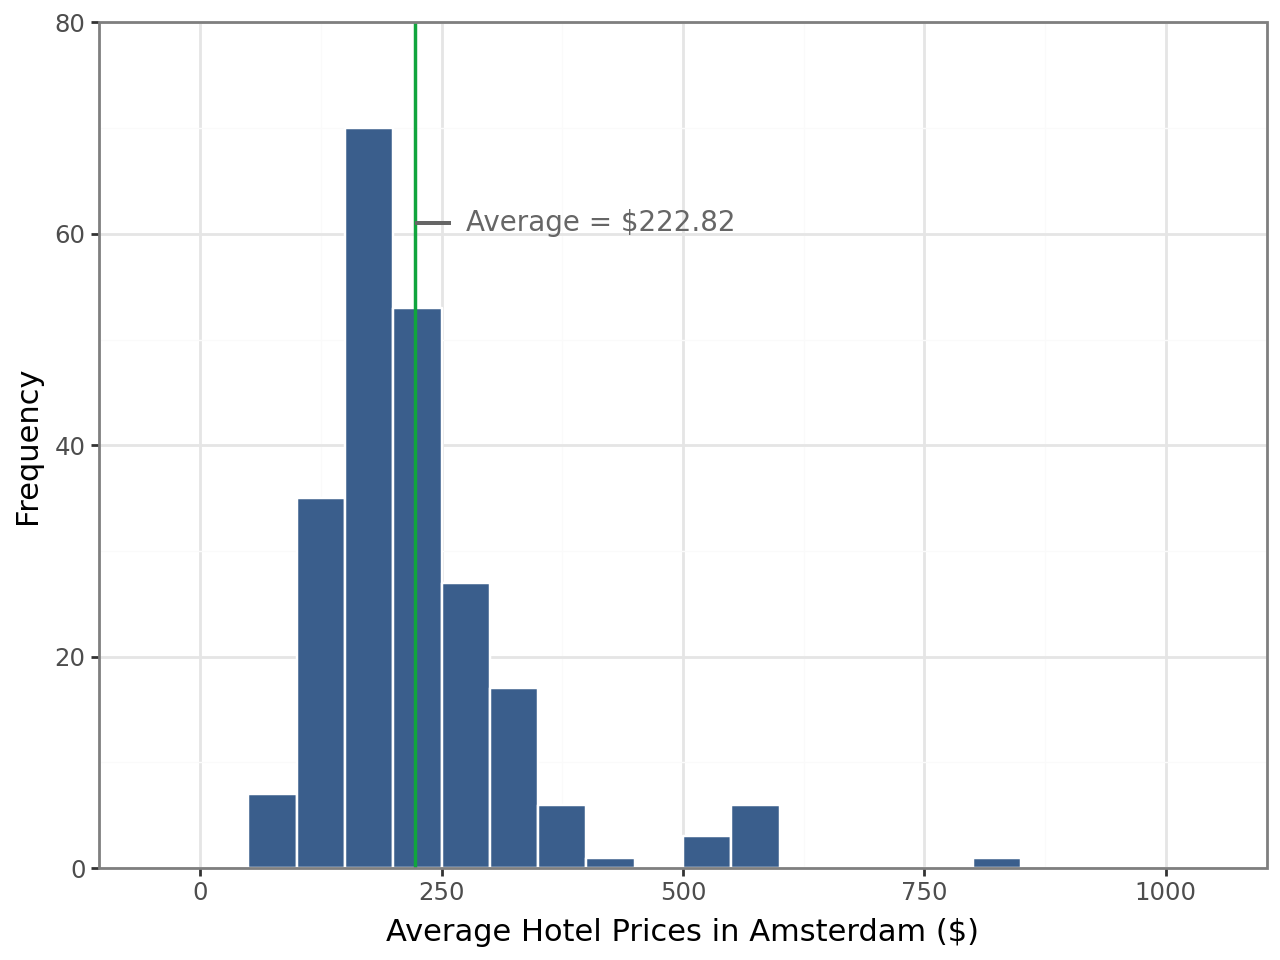

In [142]:
# ggplot(hotels_amsterdam, aes("price")) + geom_histogram(
#     fill=color[0], color="white", boundary=0, closed="left"
# ) +scale_y_continuous(expand=(0,0)
# ) + geom_segment(aes(x=260, y=61, xend=222.82, yend=61),lineend="projecting", color="#666666"
# ) + annotate(
#     "text", x=415, y=61, label="Average = $222.82", size=10, color="#666666"
# ) + theme_bw()

ggplot(hotels_amsterdam, aes("price")) + geom_histogram(
    binwidth=50, color="white",fill=color[0], boundary=0, closed="left"
) + geom_vline(xintercept=222.82, size=0.7, color=color[1]) + labs(
    x="Average Hotel Prices in Amsterdam ($)", y="Frequency"
 ) + coord_cartesian(xlim=[-50, 1050], ylim=[0, 80]
) + scale_y_continuous(expand=[0,0]
) + geom_segment(aes(x=260, y=61, xend=222.82, yend=61),lineend="projecting", color="#666666"
) + annotate(
    "text", x=415, y=61, label="Average = $222.82", size=10, color="#666666"
) + theme_bw()

We can observe that the distribution of hotel prices is skewed. With an average price of $222, we can treat it as our true value - this is our population, for the sake of this exercise. 

Next, we asssume that we don't know that this is the true value. We'll create samples based on our total population. Remember that our population is comprised of 226 hotels.

In [ ]:
amsterdam_prices = hotels_amsterdam["price"]

Create function that performs the boostrap for the mean.

In [ ]:
def create_bootstrap_samples(vector, n_samples=1000):
    """
    Performs Standard Boostrap for the Mean.
    """

    # Use the size of the original vector
    n_obs = len(amsterdam_prices)

    # Pre-allocate space (0 to n_samples-1)
    samples_mean = np.zeros(n_samples)

    for i in range(n_samples):
        single_sample = np.random.choice(vector, size=n_obs, replace=True)

        samples_mean[i] = np.mean(single_sample)

    return samples_mean

We simulated 1000 alternative realities of what "could have happened" if we collected the data again. We get a new data set, which is the **bootstrap distribution.** This list of 1000 values represents the uncertainty of the Mean.

In [ ]:
amsterdam_means = create_bootstrap_samples(amsterdam_prices)

In [ ]:
amsterdam_means

array([229.36725664, 230.77433628, 223.0619469 , 213.92035398,
       217.26106195, 220.87610619, 213.14159292, 222.19026549,
       219.61061947, 238.82743363, 210.87168142, 220.97787611,
       232.75663717, 234.94690265, 217.61946903, 217.43362832,
       220.75221239, 225.30530973, 217.85840708, 210.03539823,
       221.14159292, 229.19026549, 209.52654867, 220.92920354,
       228.44690265, 224.69911504, 228.46017699, 219.12389381,
       218.18584071, 227.18141593, 227.06637168, 224.18141593,
       223.03982301, 230.26106195, 216.01769912, 225.00884956,
       220.42477876, 216.86725664, 221.70353982, 219.57079646,
       225.4159292 , 225.70353982, 228.18584071, 220.53097345,
       219.12389381, 225.4380531 , 224.39823009, 222.70353982,
       219.25221239, 209.66814159, 235.87610619, 212.50442478,
       218.49557522, 229.33628319, 241.07079646, 216.41150442,
       216.32300885, 213.30530973, 223.03539823, 222.96902655,
       223.84513274, 219.03097345, 225.7920354 , 244.24

We can plot a histogram of this list and see what it looks like.

In [ ]:
ams_mean_df = pd.DataFrame({"price": amsterdam_means})

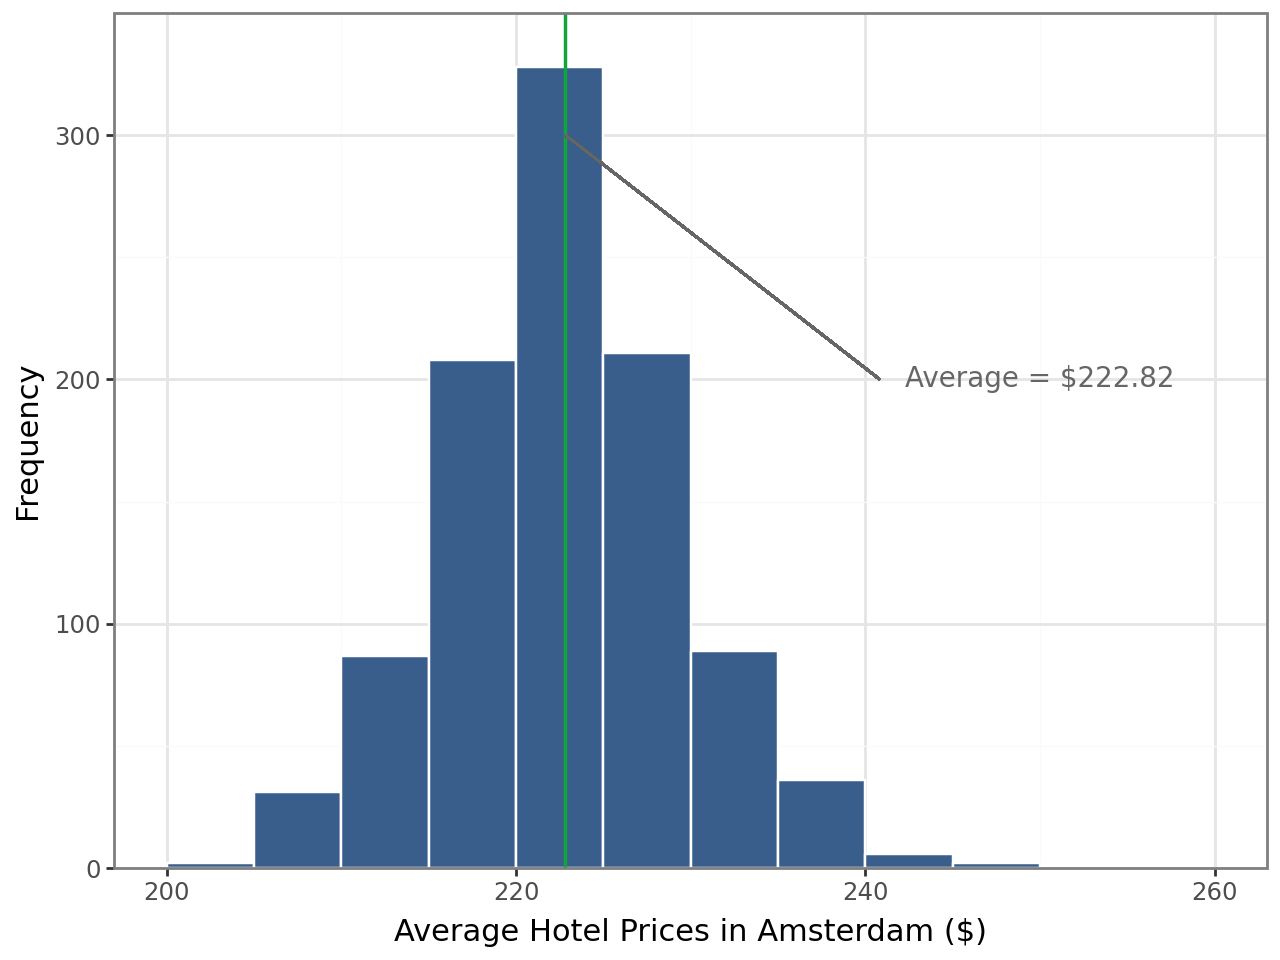

In [ ]:
ggplot(ams_mean_df, aes("price")) + geom_histogram(
    binwidth=5, color="white",fill=color[0], boundary=0, closed="left"
) + geom_vline(xintercept=222.82, size=0.7, color=color[1]) + labs(
    x="Average Hotel Prices in Amsterdam ($)", y="Frequency"
 ) + coord_cartesian(xlim=[200, 260], ylim=[0, 350]
) + scale_y_continuous(expand=[0,0]
) + geom_segment(aes(x=222.82, y=300, xend=240.82, yend=200),lineend="projecting", color="#666666"
) + annotate(
    "text", x=250, y=200, label="Average = $222.82", size=10, color="#666666"
) + theme_bw()

In [ ]:
ams_mean_df.describe()

,price
count,1000.000000
mean,222.819027
std,6.766585
min,202.783186
25%,218.560841
50%,222.688053
75%,226.902655
max,246.017699


This is very informative.
- Our bootstrap sample has, as expected, a normal distribution.
- The mean is the same of our population (222.82).
- We can already see the standard error (which is our std). 

Let's calculate these values with NumPy and the SE formula.


In [ ]:
amsterdam_SE = np.std(amsterdam_means,ddof=1)
amsterdam_SE

np.float64(6.766585475432004)

We can notice that, while our standard deviation is **102**, our Standard Error is **6.76**. How about when using the formula?

In [ ]:
SE_formula = np.std(amsterdam_prices, ddof=1) / (np.sqrt(len(amsterdam_prices)))
SE_formula


Bootstrap Bias: -0.00840707964601961


In [ ]:
Z = norm.ppf(0.975)
CI_lower = (np.mean(amsterdam_prices) - Z * amsterdam_SE) 
CI_upper = (np.mean(amsterdam_prices) + Z * amsterdam_SE)

print(f"The 95% CI is [${CI_lower:.2f}, ${CI_upper:.2f}]")

The 95% CI is [$209.57, $236.09]


In [ ]:
Aha! W